# 商品类别与偏好分析

本笔记本围绕商品类别、性别、季节、尺寸和颜色等维度，分析客户的商品偏好和市场趋势。
- 商品类别销量分布
- 不同性别对商品类别的偏好
- 季节性商品购买趋势
- 商品尺寸分布规律
- 颜色偏好分析

## 分析目标
挖掘不同群体的商品偏好特征，辅助产品开发和市场营销决策。

## 1. 导入所需库和数据

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
df.head()

数据形状: (3900, 18)
列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. 数据预处理和清洗

## 3. 商品类别销量分布

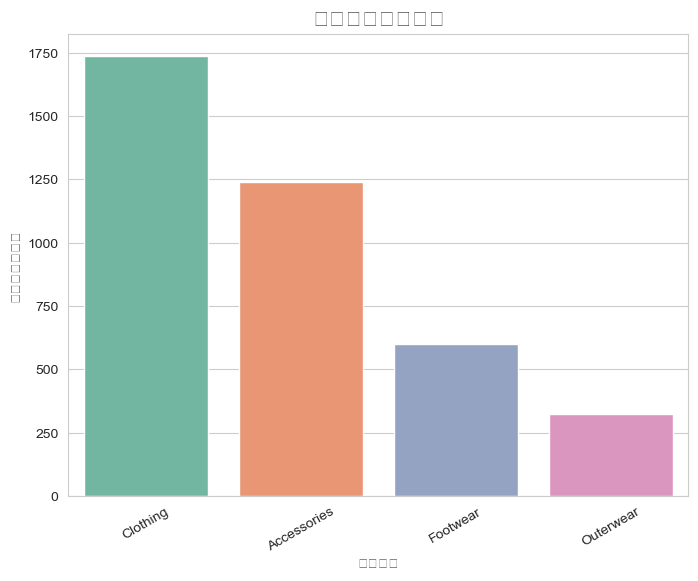

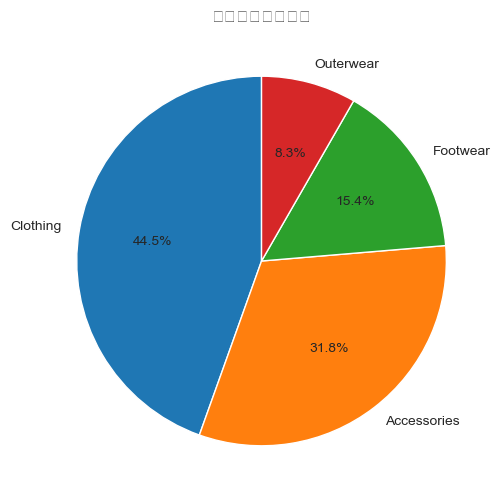

In [2]:
# 商品类别销量分布
category_counts = df['Category'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='Set2')
plt.title('商品类别销量分布', fontsize=16)
plt.xlabel('商品类别')
plt.ylabel('销量（客户数）')
plt.xticks(rotation=30)
plt.show()

# 饼图展示
plt.figure(figsize=(6,6))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('商品类别销量占比')
plt.show()

## 4. 不同性别对商品类别的偏好

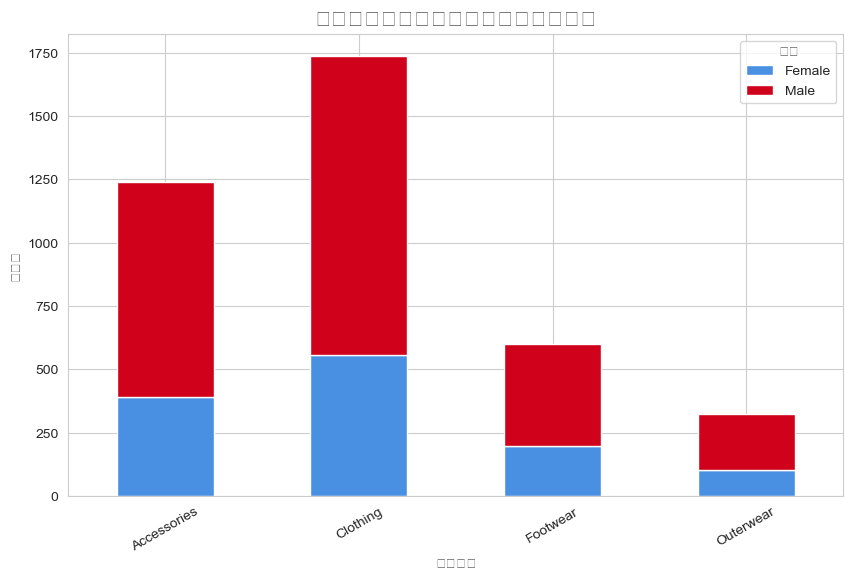

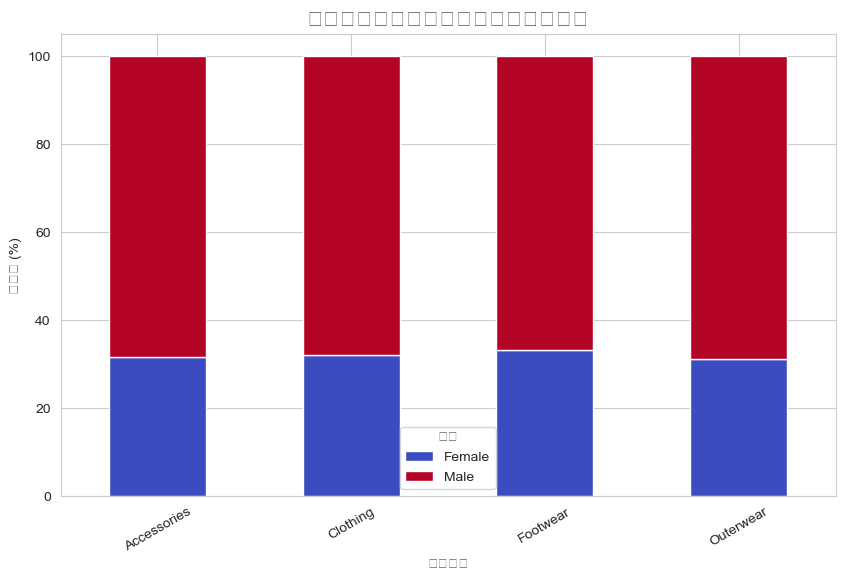

In [3]:
# 不同性别对商品类别的偏好
category_gender = pd.crosstab(df['Category'], df['Gender'])
category_gender_pct = category_gender.div(category_gender.sum(axis=1), axis=0) * 100

category_gender.plot(kind='bar', stacked=True, figsize=(10,6), color=['#4A90E2','#D0021B'])
plt.title('不同性别对商品类别的偏好（客户数）', fontsize=16)
plt.xlabel('商品类别')
plt.ylabel('客户数')
plt.xticks(rotation=30)
plt.legend(title='性别')
plt.show()

category_gender_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')
plt.title('不同性别对商品类别的偏好（百分比）', fontsize=16)
plt.xlabel('商品类别')
plt.ylabel('百分比 (%)')
plt.xticks(rotation=30)
plt.legend(title='性别')
plt.show()

## 5. 季节性商品购买趋势

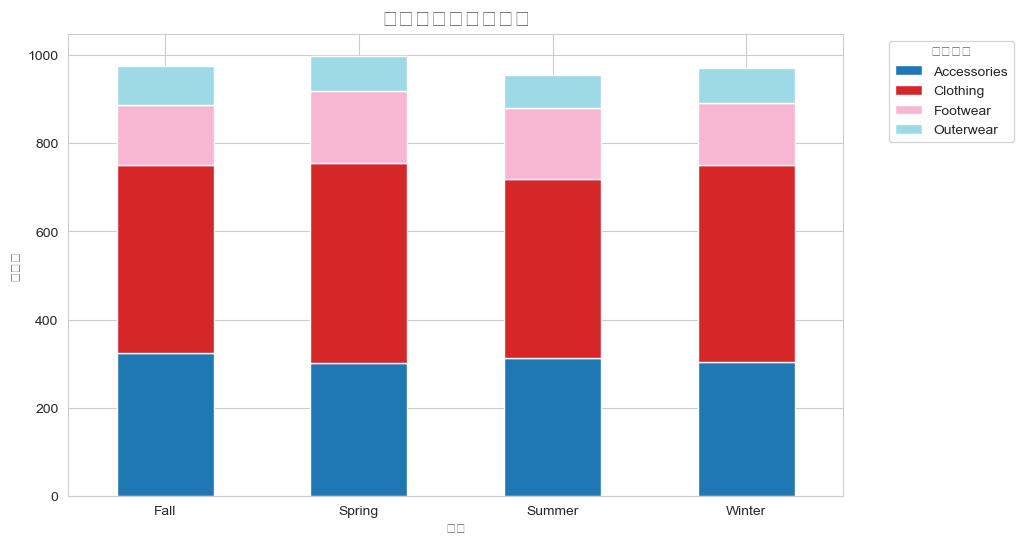

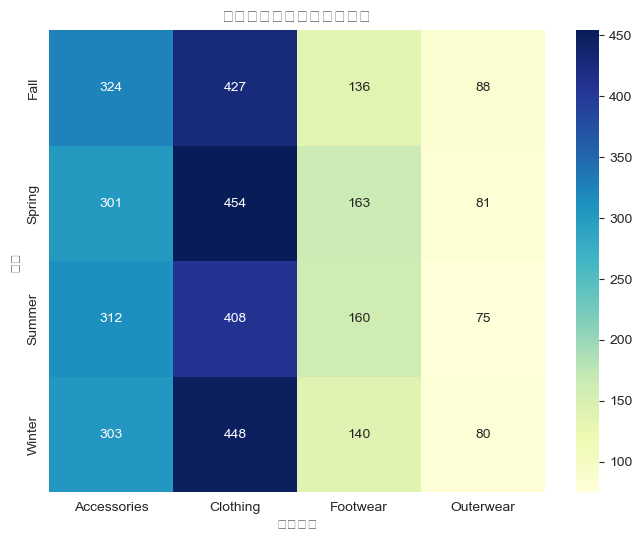

In [4]:
# 季节性商品购买趋势
season_category = pd.crosstab(df['Season'], df['Category'])
season_category.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('季节性商品购买趋势', fontsize=16)
plt.xlabel('季节')
plt.ylabel('客户数')
plt.xticks(rotation=0)
plt.legend(title='商品类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 热力图展示
plt.figure(figsize=(8,6))
sns.heatmap(season_category, annot=True, fmt='d', cmap='YlGnBu')
plt.title('季节与商品类别购买热力图')
plt.xlabel('商品类别')
plt.ylabel('季节')
plt.show()

## 6. 商品尺寸分布规律

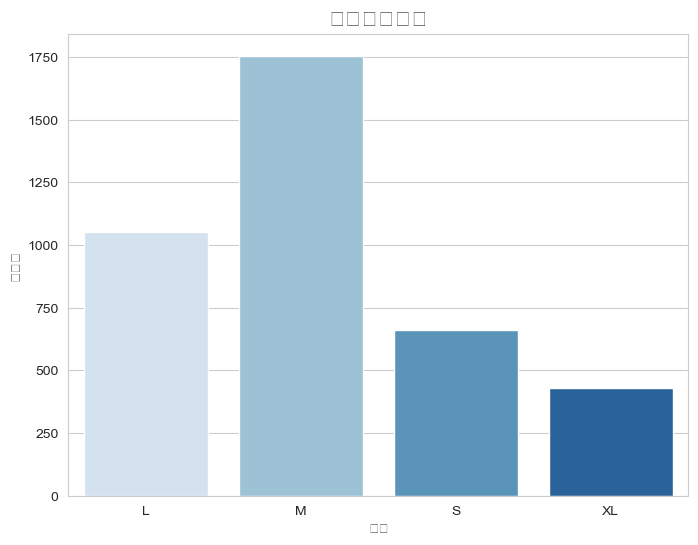

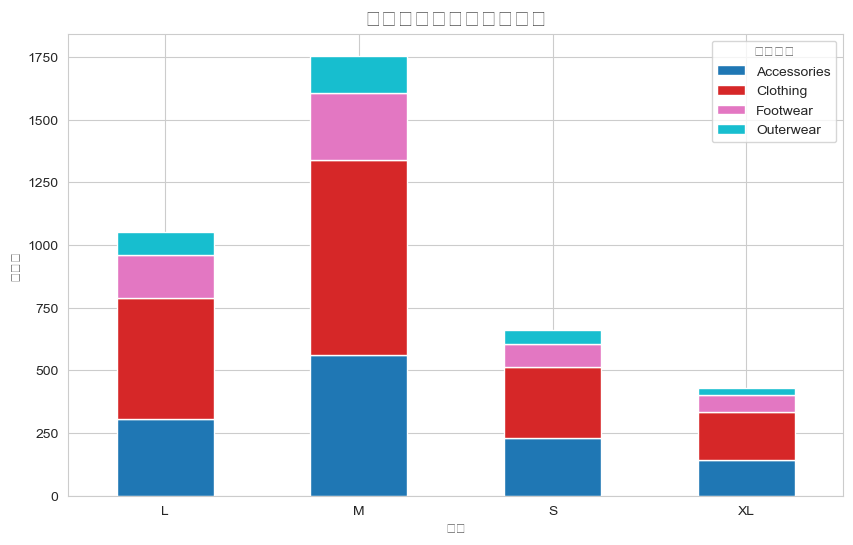

In [5]:
# 商品尺寸分布规律
size_counts = df['Size'].value_counts().sort_index()
plt.figure(figsize=(8,6))
sns.barplot(x=size_counts.index, y=size_counts.values, palette='Blues')
plt.title('商品尺寸分布', fontsize=16)
plt.xlabel('尺寸')
plt.ylabel('客户数')
plt.show()

# 尺寸与类别的关系
size_category = pd.crosstab(df['Size'], df['Category'])
size_category.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab10')
plt.title('不同尺寸的商品类别分布', fontsize=16)
plt.xlabel('尺寸')
plt.ylabel('客户数')
plt.xticks(rotation=0)
plt.legend(title='商品类别')
plt.show()

## 7. 颜色偏好分析

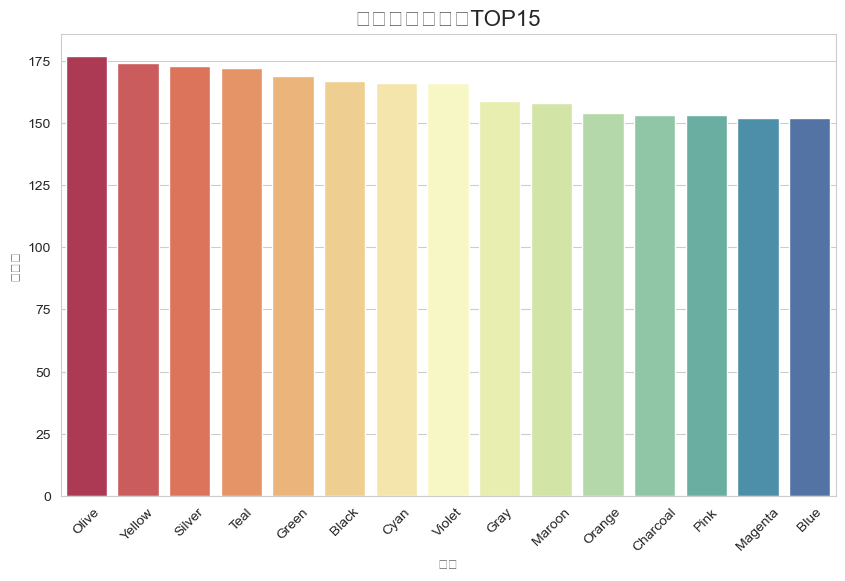

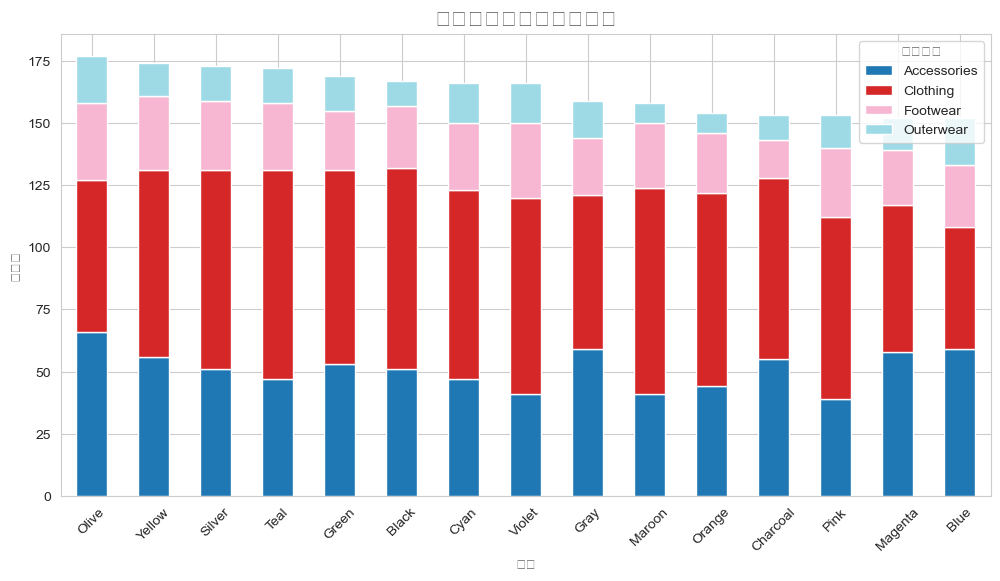

In [6]:
# 颜色偏好分析
color_counts = df['Color'].value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=color_counts.index, y=color_counts.values, palette='Spectral')
plt.title('最受欢迎的颜色TOP15', fontsize=16)
plt.xlabel('颜色')
plt.ylabel('客户数')
plt.xticks(rotation=45)
plt.show()

# 颜色与类别的关系
color_category = pd.crosstab(df['Color'], df['Category'])
color_category_top = color_category.loc[color_counts.index]
color_category_top.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title('热门颜色的商品类别分布', fontsize=16)
plt.xlabel('颜色')
plt.ylabel('客户数')
plt.xticks(rotation=45)
plt.legend(title='商品类别')
plt.show()

## 8. 主要发现与结论

- 不同商品类别销量差异明显，主流类别为Clothing、Accessories等。
- 性别对商品类别偏好有显著影响，女性更偏好某些类别。
- 季节性商品购买趋势明显，部分类别在特定季节销量突出。
- 商品尺寸分布集中在M、L、XL等主流尺寸。
- 颜色偏好呈现多样化，部分颜色在特定类别中更受欢迎。

*可结合实际业务需求，进一步细分客户群体和产品策略。*